# Salary Prediction V2

In [1]:
!python3 -m pip install pandas

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("m_employee_data.csv")

In [4]:
data.head()

,Experience_Years,Projects_Completed,Job_Title,Certificates_Completed,Salary
0,7,35,Mid,3,50691.07
1,20,44,Lead,3,86962.17
2,15,40,Senior,5,70537.40
3,11,22,Senior,4,59026.32
4,8,27,Junior,5,59124.94


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Experience_Years        100 non-null    int64  
 1   Projects_Completed      100 non-null    int64  
 2   Job_Title               100 non-null    object 
 3   Certificates_Completed  100 non-null    int64  
 4   Salary                  100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [6]:
data.shape

(100, 5)

In [7]:
data.nunique()

Experience_Years           20
Projects_Completed         40
Job_Title                   5
Certificates_Completed      6
Salary                    100
dtype: int64

In [8]:
!python3 -m pip install matplotlib 

In [9]:
from matplotlib import pyplot as plt

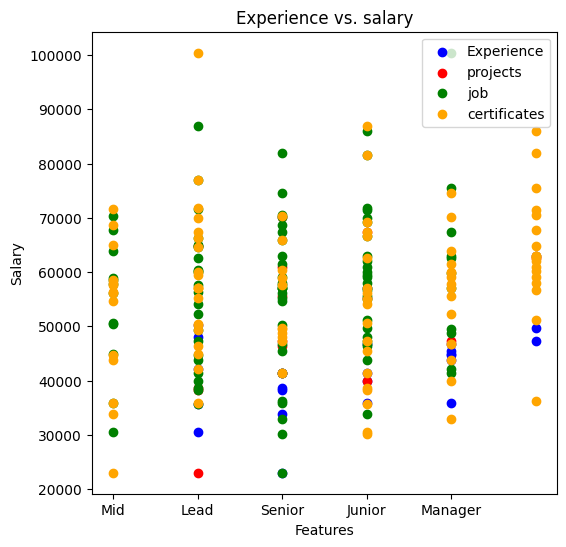

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(data['Experience_Years'], data['Salary'], color="blue", label="Experience")
plt.scatter(data['Projects_Completed'], data['Salary'], color="red", label="projects")
plt.scatter(data['Job_Title'], data['Salary'], color="green", label="job")
plt.scatter(data['Certificates_Completed'], data['Salary'], color="orange", label="certificates")
plt.xlabel("Features")
plt.ylabel("Salary")
plt.title("Experience vs. salary")
plt.legend()
plt.show()

In [11]:
data.head()

,Experience_Years,Projects_Completed,Job_Title,Certificates_Completed,Salary
0,7,35,Mid,3,50691.07
1,20,44,Lead,3,86962.17
2,15,40,Senior,5,70537.40
3,11,22,Senior,4,59026.32
4,8,27,Junior,5,59124.94


In [12]:
data_encoded = pd.get_dummies(data, columns=['Job_Title'])

In [13]:
data_encoded.head()

,Experience_Years,Projects_Completed,Certificates_Completed,Salary,Job_Title_Junior,Job_Title_Lead,Job_Title_Manager,Job_Title_Mid,Job_Title_Senior
0,7,35,3,50691.07,False,False,False,True,False
1,20,44,3,86962.17,False,True,False,False,False
2,15,40,5,70537.40,False,False,False,False,True
3,11,22,4,59026.32,False,False,False,False,True
4,8,27,5,59124.94,True,False,False,False,False


In [14]:
!python3 -m pip install scikit-learn


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
y = data_encoded['Salary']

In [17]:
X = data_encoded.drop(columns=['Salary'])

In [18]:
X.head()

,Experience_Years,Projects_Completed,Certificates_Completed,Job_Title_Junior,Job_Title_Lead,Job_Title_Manager,Job_Title_Mid,Job_Title_Senior
0,7,35,3,False,False,False,True,False
1,20,44,3,False,True,False,False,False
2,15,40,5,False,False,False,False,True
3,11,22,4,False,False,False,False,True
4,8,27,5,True,False,False,False,False


In [19]:
y

0     50691.07
1     86962.17
2     70537.40
3     59026.32
4     59124.94
        ...   
95    57014.19
96    38675.60
97    50197.07
98    60972.51
99    49593.07
Name: Salary, Length: 100, dtype: float64

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=45)

In [61]:
X_train.shape

(60, 8)

In [62]:
X_test.shape

(40, 8)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
model = LinearRegression()

In [65]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
model.fit(X_train, y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
model.coef_

array([ 1862.9631053 ,   213.66971897,   940.6132172 ,   267.54999613,
       -2544.18007447,  7880.12220501, -3004.14336301, -2599.34876366])

In [68]:
model.intercept_

np.float64(31094.57607670986)

In [69]:
predictions = model.predict(X_test)

In [70]:
predictions

array([51431.45426619, 78032.96539428, 59884.25937189, 51422.27708049,
       52549.21054416, 51959.63566824, 45576.13184189, 37865.75863   ,
       69689.52873714, 56690.58803637, 41546.62573239, 83794.27049411,
       84262.20098894, 73120.13239692, 40220.47411357, 56737.97941329,
       58811.06998942, 57942.69347018, 53019.65984953, 65239.91710021,
       56059.9513855 , 48856.45528545, 53687.56241995, 55650.82038808,
       59699.88836618, 67133.09875638, 62991.41559328, 63858.04969092,
       69221.31406607, 60213.16214544, 35358.52829591, 44840.31682884,
       75004.68396866, 64523.93595513, 63256.33305141, 68081.31862041,
       43412.84690958, 47633.78357034, 72342.75777796, 49703.83318536])

In [71]:
y_test

0     50691.07
1     86962.17
62    55255.02
76    60227.39
37    56110.52
99    49593.07
78    48109.76
38    33895.30
2     70537.40
84    56108.90
60    45464.31
26    85937.16
69    75442.14
33    70320.69
51    35886.50
4     59124.94
92    48838.77
7     58827.49
10    60027.27
74    69227.08
45    41310.92
9     43833.35
20    57719.10
18    62534.56
73    64993.88
19    32980.83
25    57078.06
21    68673.17
70    71835.49
23    60102.37
97    50197.07
90    47220.60
29    36174.65
67    67786.64
5     59828.78
82    70084.98
28    47362.06
43    46410.65
63    71399.09
66    50495.49
Name: Salary, dtype: float64

In [72]:
X_test.head(3)

,Experience_Years,Projects_Completed,Certificates_Completed,Job_Title_Junior,Job_Title_Lead,Job_Title_Manager,Job_Title_Mid,Job_Title_Senior
0,7,35,3,False,False,False,True,False
1,20,44,3,False,True,False,False,False
62,16,3,1,False,False,False,False,True


In [73]:
y_test.head(3)

0     50691.07
1     86962.17
62    55255.02
Name: Salary, dtype: float64

In [74]:
predictions

array([51431.45426619, 78032.96539428, 59884.25937189, 51422.27708049,
       52549.21054416, 51959.63566824, 45576.13184189, 37865.75863   ,
       69689.52873714, 56690.58803637, 41546.62573239, 83794.27049411,
       84262.20098894, 73120.13239692, 40220.47411357, 56737.97941329,
       58811.06998942, 57942.69347018, 53019.65984953, 65239.91710021,
       56059.9513855 , 48856.45528545, 53687.56241995, 55650.82038808,
       59699.88836618, 67133.09875638, 62991.41559328, 63858.04969092,
       69221.31406607, 60213.16214544, 35358.52829591, 44840.31682884,
       75004.68396866, 64523.93595513, 63256.33305141, 68081.31862041,
       43412.84690958, 47633.78357034, 72342.75777796, 49703.83318536])

In [75]:
from sklearn.metrics import r2_score

In [76]:
r2_score(y_test, predictions)

0.4283495143775746